## Introduction

My project will be about a Gladiator dataset with a focus on examining the features which have the greatest influence on survival. To do this, I will use Logistic Regression and Decision Tree models. Logistic Regression was chosen to be able to interpret each feature, while Decision Trees was chosen for their ability to better capture nonlinear relationships.

Here is the link to where the dataset was obtained: https://www.kaggle.com/datasets/anthonytherrien/gladiator-combat-records-and-profiles-dataset

Below are the descriptions of each column as given by the creator of the dataset:

* Name: The unique name or identifier of the gladiator.

* Age: The gladiator's age in years.

* Birth Year: The year in which the gladiator was born.

* Origin: The geographic or regional origin of the gladiator.

* Height: The height of the gladiator in centimeters.

* Weight: The weight of the gladiator in kilograms.

* Category: The classification or type of gladiator, indicating their fighting style or equipment.

* Wins: The total number of victories the gladiator has achieved.

* Losses: The total number of defeats the gladiator has suffered.

* Special Skills: Unique skills or abilities that the gladiator possesses.

* Weapon of Choice: The preferred weapon used by the gladiator in combat.

* Patron Wealth: The wealth status of the gladiator's patron or sponsor.

* Equipment Quality: The quality and condition of the gladiator's equipment.

* Public Favor: The level of popularity and favor the gladiator has with the public.

* Injury History: The historical record of injuries the gladiator has sustained.

* Mental Resilience: The gladiator's ability to withstand psychological stress and pressure.

* Diet and Nutrition: The dietary habits and nutritional regime of the gladiator.

* Tactical Knowledge: The gladiator's understanding and knowledge of combat tactics.

* Allegiance Network: The network of allies and supporters the gladiator has.

* Battle Experience: The amount of experience the gladiator has in combat.

* Psychological Profile: An assessment of the gladiator's mental state and personality traits.

* Health Status: The current health condition of the gladiator.

* Personal Motivation: The primary factor motivating the gladiator.

* Previous Occupation: The occupation of the individual before becoming a gladiator.

* Training Intensity: The intensity level of the gladiator's training regimen.

* Battle Strategy: The preferred strategy the gladiator employs in battle.

* Social Standing: The social status or rank of the gladiator.

* Crowd Appeal Techniques: Techniques used by the gladiator to appeal to the audience.

* Survived: Indicates whether the gladiator survived their combat experiences.

# Setting Up The Data

I will start by importing libraries and the dataset.

In [ ]:
import pandas as pd
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import altair as alt
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import tree
from sklearn.linear_model import LogisticRegression

from google.colab import drive
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/gladiator_data.csv'
df = pd.read_csv(file_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df

,Name,Age,Birth Year,Origin,Height,Weight,Category,Wins,Losses,Special Skills,...,Battle Experience,Psychological Profile,Health Status,Personal Motivation,Previous Occupation,Training Intensity,Battle Strategy,Social Standing,Crowd Appeal Techniques,Survived
0,Aelius Verus,32,97,Gaul,195,85,Thraex,11,4,Novice,...,15,Fearful,Good,Glory,Unemployed,Medium,Balanced,Medium,Flamboyant,False
1,Cocceius Galerius,20,32,Gaul,173,66,Hoplomachus,7,2,Speed,...,9,Fearful,Excellent,Wealth,Criminal,High,Balanced,Low,Humble,True
2,Pedius Furius,30,66,Gaul,170,67,Hoplomachus,6,0,Tactics,...,6,Stoic,Excellent,Freedom,Criminal,Low,Aggressive,Medium,Intimidating,True
3,Maximian Maecenas,28,43,Gaul,189,104,Hoplomachus,6,2,Endurance,...,8,Calculative,Excellent,Survival,Laborer,Low,Balanced,Low,Charismatic,False
4,Celsus Laronius,41,126,Rome,173,85,Hoplomachus,12,4,Novice,...,16,Calculative,Fair,Survival,Unemployed,Low,Aggressive,High,Intimidating,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9971,Sempronius Rufinus,18,55,Rome,186,47,Hoplomachus,6,2,Strength,...,8,Calculative,Excellent,Survival,Laborer,Medium,Aggressive,Medium,Intimidating,False
9972,Laelius Tertius,28,45,Thrace,178,59,Secutor,10,2,Endurance,...,12,Aggressive,Excellent,Freedom,Unemployed,Low,Defensive,High,Charismatic,True
9973,Plinius Germanicus,39,37,Thrace,185,72,Provocator,6,1,Strength,...,7,Fearful,Good,Glory,Criminal,Medium,Aggressive,Low,Charismatic,False
9974,Sentius Aelius,33,187,Numidia,173,101,Thraex,10,4,Speed,...,14,Calculative,Excellent,Survival,Criminal,Medium,Balanced,Medium,Humble,True


Below I will check to see the different classes within features so that I can adjust the strings to be numerical if applicable. This will then make it possible to use more features in the learning models.

In [ ]:
for col in df.select_dtypes(exclude='number').columns:
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print("-" * 30)

--- Name ---
Name
Clodius Urbanus         1
Aelius Verus            1
Cocceius Galerius       1
Pedius Furius           1
Maximian Maecenas       1
                       ..
Marcellus Pompeius      1
Iuventius Ingenuus      1
Sergius Mamilius        1
Vespasian Candidus      1
Quintilianus Avidius    1
Name: count, Length: 9976, dtype: int64
------------------------------
--- Origin ---
Origin
Rome        1700
Numidia     1689
Greece      1682
Germania    1659
Gaul        1633
Thrace      1613
Name: count, dtype: int64
------------------------------
--- Category ---
Category
Provocator     1771
Thraex         1715
Retiarius      1638
Secutor        1633
Hoplomachus    1626
Murmillo       1593
Name: count, dtype: int64
------------------------------
--- Special Skills ---
Special Skills
Novice       3732
Speed        1264
Endurance    1254
Strength     1249
Agility      1248
Tactics      1229
Name: count, dtype: int64
------------------------------
--- Weapon of Choice ---
Weapon of Cho

My approach for changing the strings to numbers in general will be having the lowest ranked classes like low, weak, fair, poor, or basic assigned to 0 and the highest classes like high, strong, excellent, superior, or expert are assigned to 1. Any classes in between will be spaced out evenly between 0 and 1.

I want higher numbers to represent positive attributes, so for something like injury; high will be 0 and low will be 1.

If numerical ranking could not be clearly applied with something like the "Name" feature, then I will not make any changes and the column will be removed from the dataframe later.

For "Special Skills", "Novice" will be assigned 0 and the rest will be set to 1. This will make it more of a true or false as to if they possess some special skill or not.


In [ ]:
df['Special Skills'] = df['Special Skills'].astype(str).str.strip().str.lower()
df['Special Skills'] = df['Special Skills'].apply(lambda x: 0 if x == 'novice' else 1)

wealth_map = {"Low": 0, "Medium": 1/2, "High": 1}
allegiance_map = {"Weak": 0, "Moderate": 1/2, "Strong": 1}
health_map = {"fair": 0,"good": 1/2,"excellent": 1}
equipment_map = {"Basic": 0,"Standard": 1/2,"Superior": 1}
injury_map = {"Low": 1, "High": 0}
diet_map = {"Poor": 0, "Adequate": 1/2, "Excellent": 1}
tactics_map = {"Basic": 0,"Intermediate": 1/3,"Advanced": 2/3, "Expert": 1}
training_map = {"Low": 0, "Medium": 1/2, "High": 1}
social_map = {"Low": 0, "Medium": 1/2, "High": 1}

df["Patron Wealth"] = df["Patron Wealth"].map(wealth_map)
df["Allegiance Network"] = df["Allegiance Network"].map(allegiance_map)
df["Health Status"] = df["Health Status"].astype(str).str.lower().str.strip().map(health_map)
df["Equipment Quality"] = df["Equipment Quality"].map(equipment_map)
df["Injury History"] = df["Injury History"].map(injury_map)
df["Diet and Nutrition"] = df["Diet and Nutrition"].map(diet_map)
df["Tactical Knowledge"] = df["Tactical Knowledge"].map(tactics_map)
df["Training Intensity"] = df["Training Intensity"].map(training_map)
df["Social Standing"] = df["Social Standing"].map(social_map)

Before implementing the learning models, I also want to make sure there are not any missing values.

In [ ]:
df.isnull().sum()

,0
Name,0
Age,0
Birth Year,0
Origin,0
Height,0
Weight,0
Category,0
Wins,0
Losses,0
Special Skills,0


We can see that there are no missing values, so there aren't any rows that need to be removed or adjusted.

## Examining Influences on Survival

I want to see how the features influence survival, so I will create df_s such that the "Survived" column is the only one without numerical values.

In [ ]:
df_s = df.drop(columns=["Name", "Origin", "Category", "Weapon of Choice", "Psychological Profile", "Personal Motivation", "Previous Occupation", "Battle Strategy", "Crowd Appeal Techniques"])

I will now standardize the data so that we can accurately see the affect of each feature.

In [ ]:
features = df_s.columns.drop("Survived")

df_s[features] = df_s[features].astype(float)
df_s[features] = df_s[features].apply(lambda col: (col - col.mean()) / col.std())

# Logistic Regression

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    df_s.drop(columns=["Survived"]),
    df_s["Survived"],
    train_size=0.5,
    random_state=128)

In [ ]:
reg = LogisticRegression()
reg.fit(X_train, y_train)

LogisticRegression()

In [ ]:
from sklearn.metrics import accuracy_score

acc_train = accuracy_score(y_train, reg.predict(X_train))
acc_test = accuracy_score(y_test, reg.predict(X_test))

print("Training Accuracy:", acc_train)
print("Testing Accuracy:", acc_test)
print("Difference:", abs(acc_train - acc_test))

Training Accuracy: 0.8313953488372093
Testing Accuracy: 0.8295910184442662
Difference: 0.0018043303929431431


Since the accuracy of both the train and test set are very close together, we can be confident that overfitting is not happening. Additionally, the accuracy scores themselves are relatively high indicating that the predictions are close to the actual outcomes, thus the model is working effectively.

I will now create a chart to display the coefficients of each feature for the Logistic Regression model. This will give us the information on what features impact survival the most for the model.

In [ ]:
coefs = reg.coef_[0]

features = X_train.columns

df_coef = pd.DataFrame({
    'feature': features,
    'coef': coefs
})

df_coef['abs_coef'] = df_coef['coef'].abs()
df_coef = df_coef.sort_values(by='abs_coef', ascending=False)

In [ ]:
import altair as alt

chart = alt.Chart(df_coef).mark_bar().encode(
    x=alt.X('coef:Q', title='Coefficient'),
    y=alt.Y('feature:N', sort='-x', title='Feature')
).properties(
    title='Logistic Regression Coefficients'
)

chart

alt.Chart(...)

From the chart above, the top 3 features of importance are Wins, Losses, and Mental Resilience, while the least important are Height, Weight, and Training Intensity.

The results for the top 3 are not very surprsing as it would make sense that winning more would mean you are more likely to survive and losing more would do the opposite. Additionally, having strong mental resilience would indicate that the gladiator would be able to handle the intense stress that would occur in a fight and greatly increase survival.

However, I found the bottom 3 features to be quite surprising as I assumed that all 3 would play at least some role in the outcome of survival. One possible explanation for why they didn't is because of other features which may capture those factors already.

For something like "Training Intensity", it could be overshadowed significantly by "Battle Experience" since the latter had a large influence and in itself is very similar to training.

As far as "Weight" and "Height" goes, the "Health Status" could potentially take both of their places since it may capture a relation between the two. For example, if someone was short and weighed 80kg, it would likely indicate a lower health status while if someone was tall and the same weight, their health status would be more likely to be at or above average. The converse would also apply with a tall person who is only 60kg indicating a lower health status. Thus weight and height can be hard to extrapolate from individually, but can be more influential together.

# Decision Tree

I now want to see how these same features affect survival, but when using a decision tree.

In [ ]:
cols = df_s.drop(columns=["Survived"]).columns.tolist()

X = df_s[cols]
y = df_s["Survived"]

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.6, random_state = 128)

Lets determine the best leaf node. I will be making a chart to represent the bias variance tradeoff.

I will do this by creating a new dataframe containing the columns:
* "leaves" which gives number of leaf nodes
* "error" which is the error in either the train or test set
* "set" which says if it is the train or test set

This was derived from a Twitter (X) post used in my Math 10 class that I took with Professor Hongwei Gao: https://x.com/daniela_witten/status/1292293102103748609?s=20

In [ ]:
from sklearn.tree import DecisionTreeClassifier
df_err = pd.DataFrame(columns=["leaves", "error", "set"])

for i in range(2, 30):
    clf = DecisionTreeClassifier(max_leaf_nodes=i)
    clf.fit(X_train, y_train)

    train_error = 1 - clf.score(X_train, y_train)
    test_error = 1 - clf.score(X_test, y_test)

    df_err.loc[len(df_err)] = {"leaves": i, "error": train_error, "set": "train"}
    df_err.loc[len(df_err)] = {"leaves": i, "error": test_error, "set": "test"}


In [ ]:
alt.Chart(df_err).mark_line().encode(
    x="leaves:Q",
    y= alt.Y("error:Q", scale = alt.Scale(zero = False)),
    color="set:N"
).properties(title = "Optimal Leaf Nodes")

alt.Chart(...)

From the chart we can see that the testing set line hits a low point at 14 leaf nodes then begins to go up. This indicates that we should use 14 leaf nodes in our decision tree to minimize error while still maintaining flexibility.

In [ ]:
clf = DecisionTreeClassifier(max_leaf_nodes = 14)
clf.fit(X_train, y_train)

train_score = clf.score(X_train, y_train)
test_score = clf.score(X_test, y_test)

# Print scores and their difference
print(f"Training Score: {train_score}")
print(f"Testing Score: {test_score}")
print(f"Score Difference: {abs(test_score - train_score)}")

# Create a DataFrame for feature importances
df_feature_importance = pd.DataFrame({
    'feature': cols,
    'importance': clf.feature_importances_
})

# Filter out features with 0 importance then sort
df_feature_importance = df_feature_importance[df_feature_importance['importance'] > 0]
df_feature_importance = df_feature_importance.sort_values(by='importance', ascending=False)

# Create bar chart
chart_importance = alt.Chart(df_feature_importance).mark_bar().encode(
    x=alt.X('importance', title='Importance'),
    y=alt.Y('feature', sort='-x', title='Feature')
).properties(
    title='Decision Tree Feature Importances'
)

chart_importance

Training Score: 0.8128654970760234
Testing Score: 0.7992984214482586
Score Difference: 0.013567075627764824


alt.Chart(...)

We see above that the strongest feature was public favor, and we had a testing score of almost 80% indicating that the model was able to make the correct prediction 80% of the time.

Interestingly, if we remove Public Favor, we get the following results.

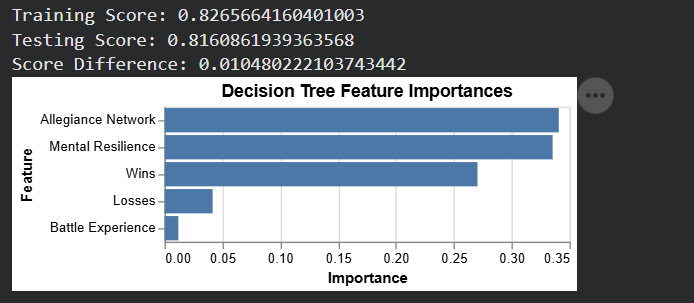

Here we see that the strongest feature is now "Allegiance Network", which previously had one of the lowest importance scores. This shift indicates a high correlation between "Allegiance Network" and "Public Favor", as the former took the latter's place once it was removed.

Not only that, but we also see that both the training and testing scores have improved. This means that "Public Favor" also had a lot of noise that reduced accuracy when it was part of the model. This demonstrates how having the most importance in a model does not necessarily mean it gives the best results.

We see that the importance of "Wins" has also gone up significantly despite it's little importance when "Public Favor" is included.

Because of this, there must also be a strong correlation between "Public Favor" and the amount of wins. I suspect the reasoning behind this is that people favor gladiators who win a lot. Although this is not a surprising find, we do see that the logic is backed up by the numbers.

Now I will examine the predictions made in the decision tree compared to the actual results using a confusion matrix.

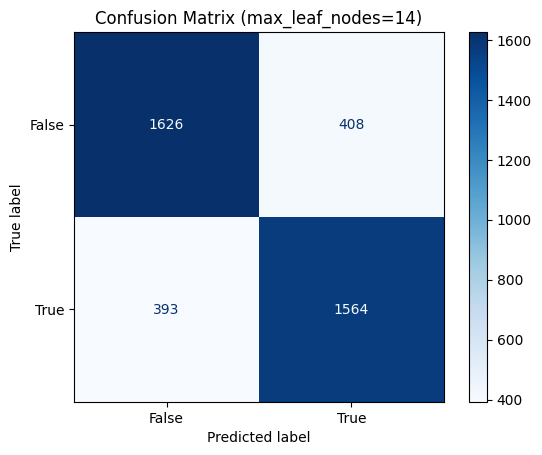


Classification Report:
              precision    recall  f1-score   support

       False       0.81      0.80      0.80      2034
        True       0.79      0.80      0.80      1957

    accuracy                           0.80      3991
   macro avg       0.80      0.80      0.80      3991
weighted avg       0.80      0.80      0.80      3991



In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

y_pred = clf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)

disp.plot(cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix (max_leaf_nodes=14)")
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Based on the confusion matrix, the model was well balanced as it correctly identified 1,626 False instances and 1,564 True instances. With a nearly even distribution of correct predictions, the results show that the model did not have a bias toward one outcome over the other. The classification report supports this further as both classes achieved a recall of 0.80. Additionally, the precision scores for False (0.81) and True (0.79) are very close, indicating that both false positives and false negatives were minimized with equal effectiveness.


I will now create a visualization for the decision tree to further extrapolate from our data.

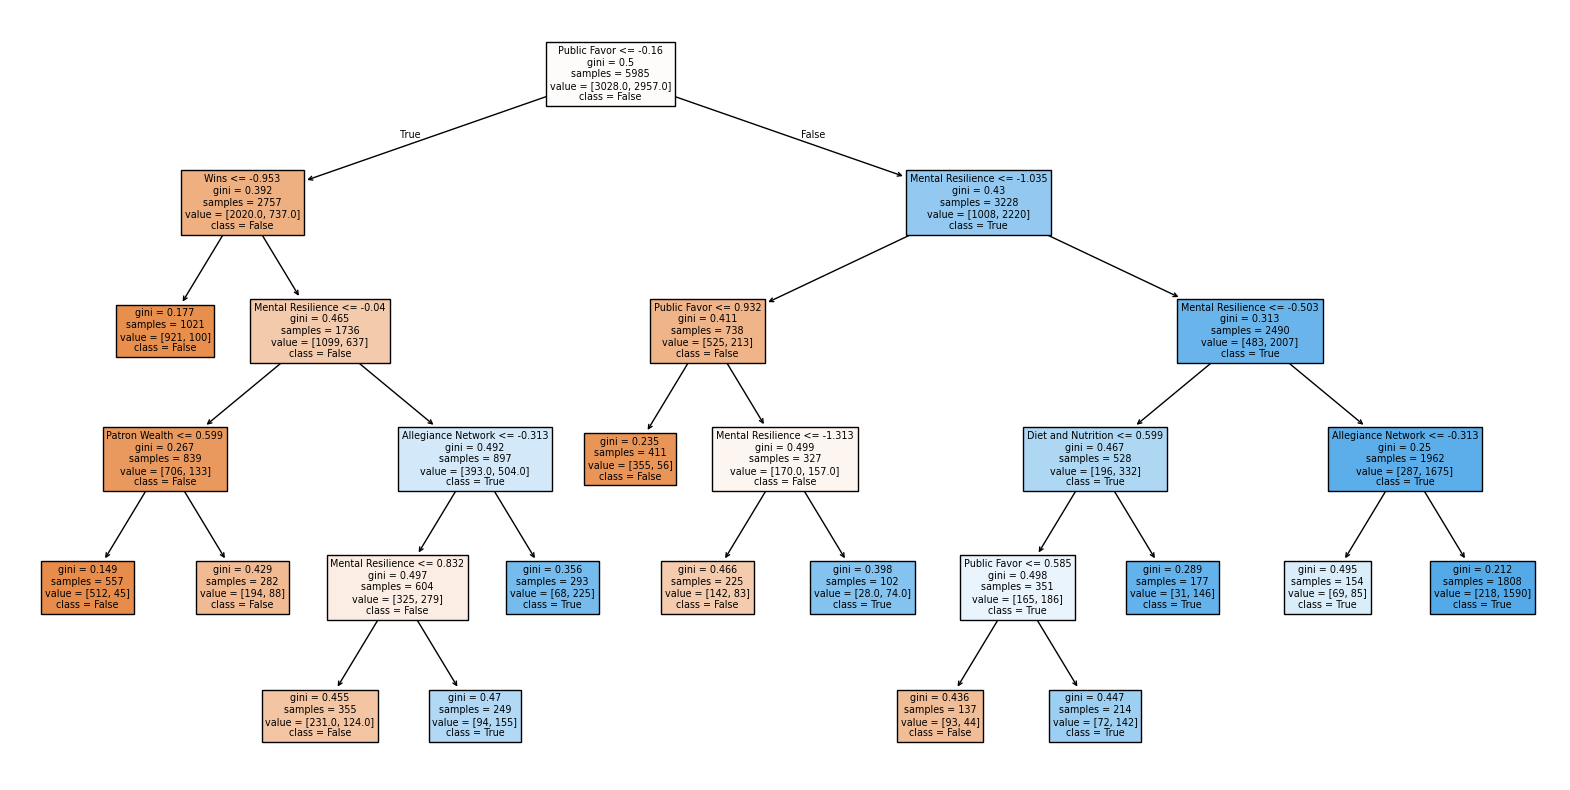

In [ ]:
fig = plt.figure(figsize=(20,10))
_ = tree.plot_tree(clf,
                   feature_names=clf.feature_names_in_,
                   class_names=[str(c) for c in clf.classes_],
                   filled=True)

From the decision tree, we can see that the node furthest to the left has the lowest gini of all nodes with a 0.149. This low number indicates that the node is the most accurate in determining between True or False. We reach this by having lower Public Favor, Wins, Mental Resilience, and Patron Wealth. One thing to note is that we obtain this without considering Diet and Nutrtion as well as Allegiance Network.

The afforementioned node returned a classification of False, so I now want to look at the lowest gini obtained for the True classification. This node is found furthest to the right and had a gini score of 0.212. Our result was obtained by having higher Public Favor, Mental Resilience, and Allegiance Network. This differs from the previous node we examined as we didn't consider Wins and we instead tightened our constraint for Mental Resilience a second time.

## Comparison of the models

Both the Logistic Regression and Decision Tree models were effective at predicting gladiator survival with high accuracy and no significant signs of overfitting. Despite the two models having different approaches, the Logistic Regression and Decision Tree models found similar results with which features were most important. The Logistic Regression model highlighted Wins, Losses, and Mental Resilience. Similarly the Decision Tree had Wins and Mental Resilience in the top 3 important features with or without Public Favor being considered.
  
The Logistic Regression model achieved a slightly higher accuracy of 83% and highlighted the negative impact of Losses, whereas the Decision Tree reached about 80% accuracy and initially had Public Favor as the strongest predictor. However, examining the Decision Tree more revealed that features like Allegiance Network and Wins are likely the reason behind the importance of Public Favor.
  
Overall, both models demonstrate that a gladiator's survival is most consistently dictated by their success in combat and their mental fortitude.




## Conclusion

In this project, I evaluated gladiator survival using Logistic Regression and Decision Tree models. Using these models I examined accuracies, most important features, and the differences of the two models. With accuracies, both models were able to achieve accuracies greater than 80%. The most consistently appearing features were "Wins" and "Mental Resilience". And finally, both models proved to be similarly effective in their results.